In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 **full ML pipeline**.

1. Collect the dataset (stock price data)
2. Load the dataset into a dataframe
3. Inspect the dataset (`head`, `info`, `describe`)
4. Understand the meaning of each column (Open, High, Low, Close, Volume)
5. Clean the data
6. Explore the data (EDA)
7. Engineer features
   * volatility (High − Low)
   * daily return
   * volume change
   * moving averages
8. Add the engineered features to the dataframe
9. Define the prediction target
   * compare tomorrow's close to today's close
   * convert to binary target (1 = up, 0 = down)
10. Handle NaN rows created by rolling windows and shifts
11. Remove rows that contain NaN values
12. Separate features and target
* **X = feature columns**
* **y = target column**
13. Split the dataset into training and testing sets
14. Choose a machine learning model
15. Train the model using the training data
16. Make predictions on the test data
17. Evaluate model performance (accuracy, precision, recall, etc.)
18. Improve the model
* try new features
* try different models
* tune parameters
19. Save the trained model
20. Use the model to predict future stock movements


In [42]:
import yfinance as yf

data = yf.download("BLK", start="2010-01-01")

[*********************100%***********************]  1 of 1 completed


In [43]:
data.to_csv("../data/blackrock_stock.csv")

In [44]:
print(data.head())
print(data.info())
print(data.describe())

Price            Close        High         Low        Open  Volume
Ticker             BLK         BLK         BLK         BLK     BLK
Date                                                              
2010-01-04  157.457352  158.130531  154.117869  155.787610  238700
2010-01-05  158.137100  158.176697  156.256162  157.767515  198800
2010-01-06  154.876801  157.503506  154.474214  157.411110  278500
2010-01-07  156.579559  156.876547  154.434634  154.870221  218300
2010-01-08  157.681747  158.005140  156.249598  156.718186  224400
<class 'pandas.DataFrame'>
DatetimeIndex: 4068 entries, 2010-01-04 to 2026-03-06
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, BLK)   4068 non-null   float64
 1   (High, BLK)    4068 non-null   float64
 2   (Low, BLK)     4068 non-null   float64
 3   (Open, BLK)    4068 non-null   float64
 4   (Volume, BLK)  4068 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 

cleaning the data 

In [45]:
df = data.dropna()
df.drop_duplicates(inplace=True)
valid_numeric_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df.dtypes

print(df.head())

Price            Close        High         Low        Open  Volume
Ticker             BLK         BLK         BLK         BLK     BLK
Date                                                              
2010-01-04  157.457352  158.130531  154.117869  155.787610  238700
2010-01-05  158.137100  158.176697  156.256162  157.767515  198800
2010-01-06  154.876801  157.503506  154.474214  157.411110  278500
2010-01-07  156.579559  156.876547  154.434634  154.870221  218300
2010-01-08  157.681747  158.005140  156.249598  156.718186  224400


create features 

In [46]:
volatility = df['High'] - df['Low']
print(volatility.head())
daily_return = df['Close'].pct_change()
print(daily_return.head())
volume_change = df['Volume'].pct_change()
print(volume_change.head())
five_day_average = df['Close'].rolling(window=5).mean()
print(five_day_average.head())


Ticker           BLK
Date                
2010-01-04  4.012662
2010-01-05  1.920536
2010-01-06  3.029292
2010-01-07  2.441913
2010-01-08  1.755542
Ticker           BLK
Date                
2010-01-04       NaN
2010-01-05  0.004317
2010-01-06 -0.020617
2010-01-07  0.010994
2010-01-08  0.007039
Ticker           BLK
Date                
2010-01-04       NaN
2010-01-05 -0.167155
2010-01-06  0.400905
2010-01-07 -0.216158
2010-01-08  0.027943
Ticker             BLK
Date                  
2010-01-04         NaN
2010-01-05         NaN
2010-01-06         NaN
2010-01-07         NaN
2010-01-08  156.946512


In [47]:
df["Volatility"] = volatility
df["Daily Return"] = daily_return
df["Volume Change"] = volume_change
df["five day average"] = five_day_average
df.head()


Price,Close,High,Low,Open,Volume,Volatility,Daily Return,Volume Change,five day average
Ticker,BLK,BLK,BLK,BLK,BLK,,,,
Date,,,,,,,,,
2010-01-04,157.457352,158.130531,154.117869,155.787610,238700,4.012662,NaN,NaN,NaN
2010-01-05,158.137100,158.176697,156.256162,157.767515,198800,1.920536,0.004317,-0.167155,NaN
2010-01-06,154.876801,157.503506,154.474214,157.411110,278500,3.029292,-0.020617,0.400905,NaN
2010-01-07,156.579559,156.876547,154.434634,154.870221,218300,2.441913,0.010994,-0.216158,NaN
2010-01-08,157.681747,158.005140,156.249598,156.718186,224400,1.755542,0.007039,0.027943,156.946512


Prediction target 
using binary classification for simplicity 

In [48]:
# correct the target column with a vectorised calculation
# 1 if next‑day close is higher than today, 0 otherwise
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# the last row gets NaN from the shift, make it 0 (or drop it later)
df['Target'].fillna(0, inplace=True)

df['Target'].head()

C:\Users\summe\AppData\Local\Temp\ipykernel_8732\3462387842.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Target'].fillna(0, inplace=True)


Date
2010-01-04    1
2010-01-05    0
2010-01-06    1
2010-01-07    1
2010-01-08    1
Name: Target, dtype: int64

handle NaN rows

In [49]:
df = df.dropna()
print(df.head())

Price            Close        High         Low        Open  Volume Volatility  \
Ticker             BLK         BLK         BLK         BLK     BLK              
Date                                                                            
2010-01-08  157.681747  158.005140  156.249598  156.718186  224400   1.755542   
2010-01-11  160.249084  160.902466  158.361549  158.361549  207900   2.540917   
2010-01-12  157.384766  160.499859  157.384766  159.212905  208100   3.115093   
2010-01-13  158.011703  158.361491  154.579825  154.579825  203400   3.781666   
2010-01-14  157.008591  158.585936  156.414615  157.846765  163900   2.171321   

Price      Daily Return Volume Change five day average Target  
Ticker                                                         
Date                                                           
2010-01-08     0.007039      0.027943       156.946512      1  
2010-01-11     0.016282     -0.073529       157.504858      0  
2010-01-12    -0.017874      0.

Seperate features and target 

In [50]:
feature_columns = [
    "Volatility",
    "Daily Return",
    "Volume Change",
    "five day average"
]
X = df[feature_columns]

Y = df['Target']

training and testing split 

In [54]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state = 50, test_size = 0.25)
# print the total number of training set (records)
print(np.shape(y_train))

# print the total number of test set (records)
print(np.shape(y_test))

(3048,)
(1016,)


choosing and training model


accuracy: 0.52
Confusion Matrix:[[ 20 459]
 [ 25 512]]
Precision: 0.53
Recall: 0.95
F1 Score: 0.68


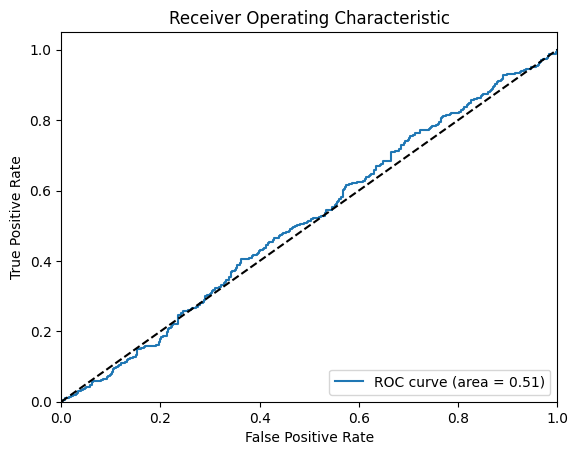

In [61]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:" + str(cm))
precision = precision_score(y_test, y_pred)
print(f"Precision: {round(precision,2)}")
recall = recall_score(y_test, y_pred)
print(f"Recall: {round(recall,2)}")
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {round(f1,2)}")
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


USING A KNN MODEL FOR VARIATION

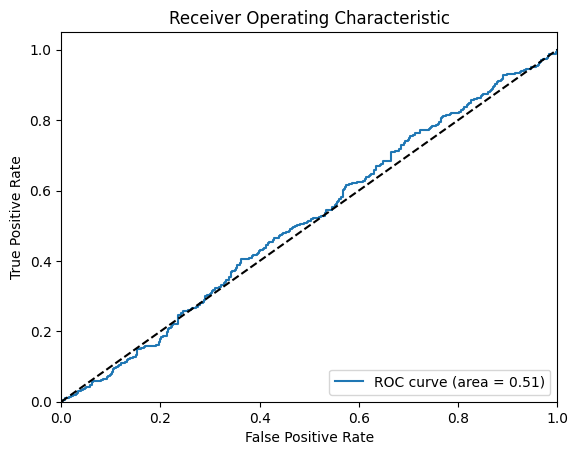

accuracy: 0.51


In [65]:
# Import Library for KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

# Create a training model KNeighborsClassifier
model_1 = KNeighborsClassifier()
model_1.fit(X_train, np.ravel(y_train))
# Model Evaluation
pred=model_1.predict(X_test)

# predict the class of the first 10 lines of the X_test dataset. The return will be an array containing the estimated categories.
y_test[0:10]
model_1.score(X_test, y_test)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, model_1.predict(X_test))
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
accuracy = accuracy_score(y_test, pred)
print(f"accuracy: {round(accuracy,2)}")

using a 3rd model and using a train test split according to date

Mean Squared Error: 0.28
Predicted value for the first test data point: 0.67
Actual value for the first test data point: 0.00


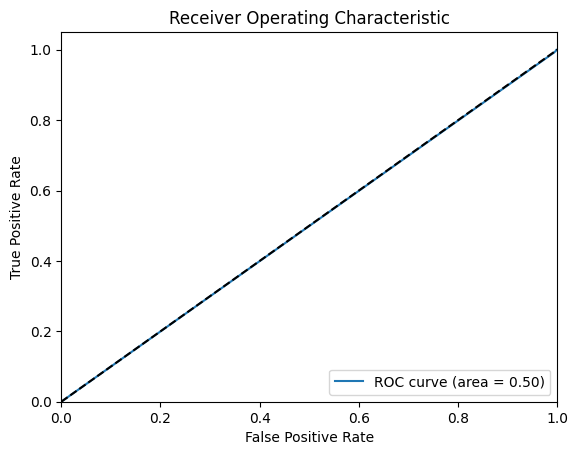

accuracy: 0.5


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = df.sort_index()
split_index = int(len(df) * 0.75)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = Y.iloc[:split_index]
y_test = Y.iloc[split_index:]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
y_pred = rf.fit(X_train, y_train).predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
single_data = X_test.iloc[0].values.reshape(1, -1)
single_pred = rf.predict(single_data)
print(f"Predicted value for the first test data point: {single_pred[0]:.2f}")
print(f"Actual value for the first test data point: {y_test.iloc[0]:.2f}")

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, model_1.predict(X_test))
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
accuracy = accuracy_score(y_test, pred)
print(f"accuracy: {round(accuracy,2)}")

